# Exercise 3 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: Cyril Nils Goffin

Sciper number: 373937

#### Group Member 2:
Name: Emilien Constant Eugène Coudurier

Sciper number: 345431

#### Group Member 3:
Name: Moritz Fredrik Tschudin 

Sciper number: 327569

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

Disclaimer: AI tools were used to assist with LaTeX formatting of equations in Markdown (e.g., alignment and syntax).

In [1]:
### Do the imports -- no need to change this
import numpy as np
from typing import List
import matplotlib.pyplot as plt
plt.style.use('default')
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

# Ex 1: Prove of the Policy Gradient Theorem via the Performance Difference Lemma (20 points)

Denote $J(\pi) = \langle \mu, V^\pi \rangle$ and recall that the performance difference lemma states
$$
J(\pi) - J(\pi') = \frac{1}{(1-\gamma)}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]
$$
where $\lambda^{\pi'} \in \Delta_{\mathcal{S}\times\mathcal{A}}$ denotes the occupancy measure of the policy $\pi'$.

Now let us consider direct parametization, and compute a partial derivative for the entry of $\pi$ at index $(\bar{s},\bar{a})$:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}.
$$

**Questions**

To help you compute this partial derivative, consider the policies $\pi'$ parameterized by some (sufficiently small) $\delta \in \mathbb{R}$ via
$$
    \pi'(a|s) = \begin{cases}
        \pi(\bar{a}|\bar{s}) + \delta \quad (\text{if } (s,a)=(\bar{s},\bar{a}))\\
        \pi(a|s) \quad (\text{else})
    \end{cases}
$$

(1) Argue that
$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}.
$$

**Answer**

From the performance difference lemma and the differentiability definiton, we have:

\begin{align*}
    \frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} &= \lim_{\delta \rightarrow 0} \frac{J(\pi + \delta) - J(\pi)}{\delta}, \\

    &= \lim_{\delta \rightarrow 0} \frac{-(J(\pi') - J(\pi))}{\pi(\bar{a}|\bar{s}) - \pi(\bar{a}|\bar{s}) - \delta}, \\

    &= \lim_{\delta \rightarrow 0} \frac{J(\pi) - J(\pi')}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}, \\
    
    &= \lim_{\delta \rightarrow 0} \frac{1}{(1-\gamma)} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}. \\

    \square
\end{align*}

(2) Argue that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).$$

Hint: Write the expectation in the previous question as a sum and use the fact that $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}}$.

**Answer**

We take the result from 1) and rewrite the expectation using a sum:

\begin{align*}
    \frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} &= \lim_{\delta \rightarrow 0} \frac{1}{(1-\gamma)} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}, \\

    &= \lim_{\delta \rightarrow 0} \frac{1}{(1-\gamma)} \frac{\sum_{s \in \mathcal{S}} \lambda^{\pi'} (s) \sum_{a \in \mathcal{A}} (\pi(a|s) - \pi'(a | s) ) Q^\pi(s, a)}      {\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}. 
\end{align*}

From the hint, we know $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}}$, and by putting the denominator into the second sum we get:

\begin{align*}
    \frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} 

    &= \lim_{\delta \rightarrow 0} \frac{1}{(1-\gamma)} \sum_{s \in \mathcal{S}} \lambda^{\pi'} (s) \sum_{a \in \mathcal{A}} \left( \frac{\pi(a|s) - \pi'(a | s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} \right) Q^\pi(s, a), \\

    &= \lim_{\delta \rightarrow 0} \frac{1}{(1-\gamma)} \sum_{s \in \mathcal{S}} \lambda^{\pi'} (s) \sum_{a \in \mathcal{A}} \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}} Q^\pi(s, a).
\end{align*}

By definition, the indicator evaluates to 1 only when $(s, a) = (\bar{s}, \bar{a})$ thus:

\begin{align*}
    \frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} 
    &= \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).
\end{align*}

$\square$

(3) Conclude that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$$
for the direct parameterization. 

**Answer**

From the result obtained in 2), we can directly evaluates the limit which only applies to $\lambda^{\pi'}$, where $\lim_{\delta \rightarrow 0} \pi'(a|s) = \pi(a|s)$:

\begin{align*}
    \frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} 
    &= \frac{1}{(1-\gamma)} Q^\pi(\bar{s}, \bar{a}) \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) \\

    &= \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).
\end{align*}

$\square$

(4) Prove that for a general parametrization, it holds that
$$
\nabla_\theta J(\pi_\theta) = \frac{1}{(1-\gamma)} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} ( \log \pi_\theta(\bar{a}|\bar{s}))
$$

Hint: Use the chain rule to write $$ \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}), $$
and then use the fact that $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s}) \pi(\bar{a}|\bar{s})$.

**Answer**

From the chain rule, we have:

\begin{align*}
    \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}).
\end{align*}

By replacing the expression of the partial derivative we obtained previously in the sum we have:

\begin{align*}
    \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}).
\end{align*}

We use the identity $\nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}) = \pi_\theta(\bar{a}|\bar{s}) \nabla_{\theta} \log \pi_\theta(\bar{a}|\bar{s})$ and insert it in the sum to obtain:

\begin{align*}
    \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a}) \pi_\theta(\bar{a}|\bar{s}) \nabla_{\theta} \log \pi_\theta(\bar{a}|\bar{s}).
\end{align*}

Because $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s}) \pi(\bar{a}|\bar{s})$ and because $\frac{1}{(1-\gamma)}$ is independent of the sum indices, we can reduce the expression to:

\begin{align*}
    \nabla_\theta J(\pi_\theta) &= \sum_{\bar{s},\bar{a}} \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} \log \pi_\theta(\bar{a}|\bar{s}), \\

    &= \frac{1}{(1-\gamma)} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} \log \pi_\theta(\bar{a}|\bar{s}), \\
\end{align*}

$\square$

This concludes the proof.

# Ex 2: Natural Policy Gradient with softmax parameterization (20 points)

Recall that the iterates $\{\pi^t\}^{\infty}_{t=1}$ produced by NPG read as follows:
$$
\pi^{t+1}(a|s) = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
$$

Implement NPG for an arbitrary step size $\eta$. Please note that $e^{\eta Q^{\pi^t}(s,a)}$ can be zero, account for that in your implementation.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [2]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy stochastic passed with shape n_states times n_actions
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s].dot(pi[s])
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

def npg_update(q, eta, old_policy):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        new_policy: the updates policy
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s] = old_policy[s] * np.exp(eta * (q[s] - max(q[s])))    # ADDED: unnormalized update, substracting max(q) to preserve numerical stability
        total = np.sum(policy[s])
        if total == 0:
             policy[s] = np.ones(q.shape[1])/q.shape[1]
        else:
            policy[s] = policy[s] / total                               # ADDED: normalization step
    return policy

def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s,np.argmax(q[s,:])] = 1
    return policy

In [3]:
def NPG(env, eta): # apply NPG iterations for 30 steps
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.ones_like(q)/env.n_actions
    for k in range(30):
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env)
        if eta < np.inf:
            pi = npg_update(q, eta, pi)
        else:
            pi = get_greedy_policy(q)
        vs.append(v)
        policies.append(pi)
    return vs, policies

Now, we run NPG for different stepsizes in the usual gridworld environment

In [4]:
reward_mode = 2
size = 10 
prop = 0
gamma=0.99
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
mu = np.ones(gridworld.n_states)/gridworld.n_states
etas = [1e-3, 1e-2, 1e-1, 1, 100, 1e7, np.inf]
v_different_etas = []
pi_different_etas = []
for eta in etas:
    values_pi, policies = NPG(gridworld, eta=eta)
    v_different_etas.append(values_pi)
    pi_different_etas.append(policies)

In [5]:
solver = MDPsolver(gridworld)
solver.value_iteration()

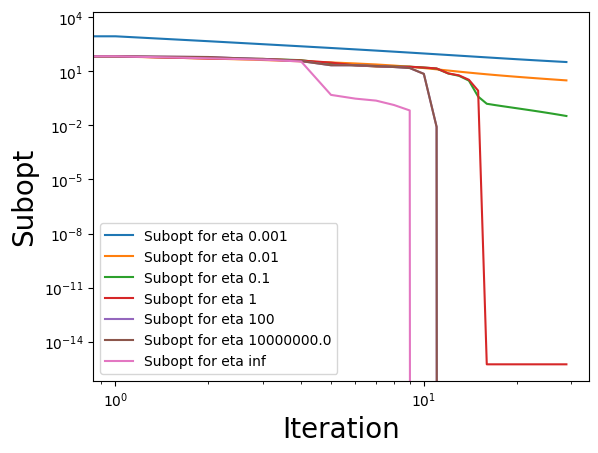

In [6]:
# TODO: if this plot appears with a too large legend, rerun this line once more
plot_log_lines([np.array([mu.dot(solver.v - v) for v in v_different_etas[i]]) for i, _ in enumerate(etas)], [f"Subopt for eta {eta}" for eta in etas], ["Iteration", "Subopt"], "figs", "NPG.pdf", show = True)

**Question**

Show that NPG with $\eta = \infty$ coincides with Policy Iteration (PI).

More formally: Assuming that $a^\star_s := \mathrm{argmax}_a Q^{\pi^t}(s,a)$ is unique for all $s$, prove that $$ \lim_{\eta \rightarrow \infty} \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \begin{cases} 1 \quad \text{if} \quad a = a^\star_s \\ 0 \quad \text{otherwise} \end{cases},$$
and explain how this relates to PI.

**Answer**

Recall that NPG iterates are:

\begin{align*}
    \pi^{t+1}(a|s) = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
\end{align*}

Taking $\eta \rightarrow \infty$ we get:

\begin{align*}
    \lim_{\eta \rightarrow \infty} \pi^{t+1}(a|s) &= \lim_{\eta \rightarrow \infty}
    \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
\end{align*}

Because $e^{\eta Q^{\pi^t}(s,a)}$ explodes for small increases in $Q^{\pi^t}(s,a)$, and because $\forall a \neq a^\star_s$ we have $Q^{\pi^t}(s,a) < a^\star_s$, the denominator goes to infinity with rate:

\begin{align*}
    \pi^t(a^\star_s|s) e^{\eta Q^{\pi^t}(s,a^\star_s)} \propto e^{\eta Q^{\pi^t}(s,a^\star_s)},
\end{align*}
 
While the numerator goes to infinity with rate:
 
\begin{align*}
    \pi^t(a|s) e^{\eta Q^{\pi^t}(s,a)} \leq \pi^t(a^\star_s|s) e^{\eta Q^{\pi^t}(s,a^\star_s)}.
\end{align*}

More formally, by dividing both numerator and denominator by $e^{\eta Q^{\pi^t}(s,a^\star_s)}$ and because $Q^{\pi^t}(s,a) - Q^{\pi^t}(s,a^\star_s) < 0$ (since $a^\star$ is considered unique) we get:

\begin{align*}
    \lim_{\eta \rightarrow \infty} \pi^{t+1}(a|s) &= \lim_{\eta \rightarrow \infty}
    \frac{\pi^t(a|s)e^{\eta (Q^{\pi^t}(s,a) - Q^{\pi^t}(s,a^\star_s))}}{\sum_{a'} \pi^t(a'|s) e^{\eta (Q^{\pi^t}(s,a') - Q^{\pi^t}(s,a^\star_s))}} 
\end{align*}

Which let us conclude that:

\begin{align*}
    \lim_{\eta \rightarrow \infty} \pi^{t+1}(a|s) 
    
    = \begin{cases} \frac{\pi^t(a^\star|s)}{\pi^t(a^\star|s)} = 1 \quad \text{if} \quad a = a^\star_s \\ \frac{0}{\pi^t(a^\star|s)} = 0  \quad \text{otherwise} \end{cases}.
\end{align*}

$\square$

This means that the policy will be updated to 1 for the best action and 0 otherwise. Since policy iteration is:

\begin{align*}
    \pi^{t+1}(a|s) = \argmax_{a \in \mathcal{A}} Q^{\pi^t}(s,a) = \begin{cases} 1 \quad \text{if} \quad a = a^\star_s \\ 0 \quad \text{otherwise} \end{cases},
\end{align*}

It is clear that NPG with $\eta \rightarrow \infty$ is equivalent to PI.

**Question**

Is this observation in line with the empirical results in the plot above? I.e., is the plot for $\eta = \infty$ as you would expect it for PI?

**Answer**

Yes, this is in line with empirical results. I.e., NPG with $\eta = \infty$ has an infinite step size which pushes aggressively the probability distribution entirely towards the single best action. We can see that this behavior is less and less aggressive as $\eta$ goes to 0, offering a smaller and smaller continuous finite step in the direction of the policy gradient.

# Ex 2.2 Slow Changing Property of NPG

In this exercise you will investigate by how much consecutive iterates $\pi^t$ and $\pi^{t+1}$ produced by NPG differ and how this distance is controlled by the step size $\eta$.

Plot $$\max_{s \in \mathcal{S}} || \pi^{t+1}(a|s) - \pi^t(a|s) ||_1$$ for different values of $\eta$.

In [7]:
def compute_policy_variation(policies):
    variation = []
    for pi, pip in zip(policies[1:], policies[:-1]):
        variation.append(np.max([ np.linalg.norm(pip[s] - pi[s], 1) for s in range(pi.shape[0])])) # ADDED
    return variation

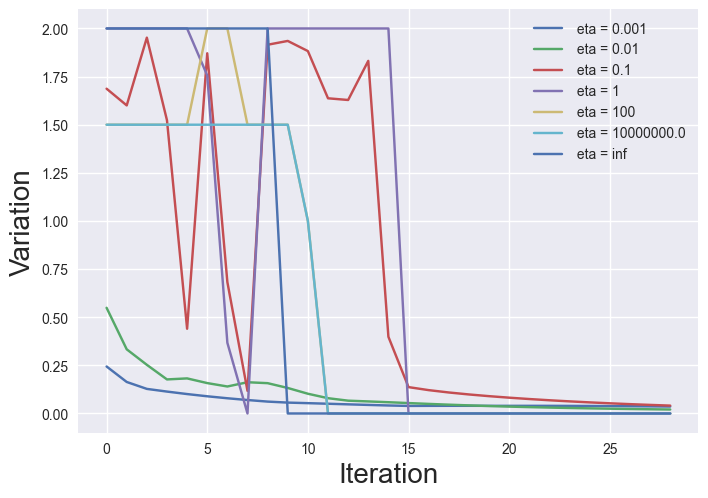

In [8]:
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)]), 
               [f" eta = {eta}" for eta in etas], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)

**Question**

Empirically, is the largest change (among all iterations) between consecutive iterations is larger for smaller or large values of $\eta$?

The largest change for two consecutive iterations occurs for large values of $\eta$. This is not surprising, since $\eta$ is a parameter that relates to the 'aggressiveness' of an update step, where $\eta = \infty$ is PI as detailed above. 

## Some Theory to Motivate the Observation Above

**Question**

Our goal is to prove that $$ || \pi^{t+1}(\cdot|s) - \pi^t(\cdot|s) ||_1 \leq \frac{\eta}{1 - \gamma} \quad \forall s \in \mathcal{S}, \forall t \in [T].$$

We guide you towards this result by breaking the proof into small steps.

1) Prove that $$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log \bigg(\sum_{a'\in\mathcal{A}} \pi^t(a'|s) \exp (\eta Q^{\pi^t}(s,a'))\bigg) $$

Hint: First apply Pinkser's inequality https://en.wikipedia.org/wiki/Pinsker%27s_inequality to prove that $$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq KL(\pi^{t+1}(s)||\pi^t(s)), $$ then plug in the formula for $\pi^{t+1}$ into the KL term.

**Answer**

Pinsker's inequality states that, if $P$ and $Q$ are two probability distributions on a measurable space $(X, \Sigma)$ then:

\begin{align*}
    sup{ |P(A) - Q(A) | } = \sqrt{ \frac{1}{2} D_{KL} (P || Q) }.
\end{align*}

It follows that:

\begin{align*}
    sup{ |P(A) - Q(A) | } &= \sqrt{ \frac{1}{2} D_{KL} (P || Q) }, \\

    &\Leftrightarrow \\

    || \pi^{t+1}(s) - \pi^t(s) ||^2_1 &\leq \frac{1}{2} D_{KL} (\pi^{t+1}(s) || \pi^t(s)), \\

    &\Rightarrow \\

    \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 &\leq D_{KL} (\pi^{t+1}(s) || \pi^t(s)).
\end{align*}

Where $D_{KL} (P || Q) = \mathbb{E}_P \left( \log \frac{dP}{dQ} \right)$. By definition:

\begin{align*}
    \pi^{t+1}(a|s) 
    
    = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} 
    
    = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\kappa}.
\end{align*}

Where $\kappa$ is used to denote the denominator for readability.

We can plug this into the right hand side of last equation, and use that $\mathbb{E}_P = \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}$ (since $P = \pi^{t+1}(s)$) and end up with:

\begin{align*}
    \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 &\leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} \left( \log \frac{\pi^t(s)e^{\eta Q^{\pi^t}(s,a) }}{\kappa \pi^t(a|s)} \right), \\

    &\Leftrightarrow \\

    \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 &\leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} \left( \eta Q^{\pi^t}(s,a) - \log(\kappa) \right).
\end{align*}

Because $\mathbb{E}(c) = c, \forall c \in \mathbb{R}$, we finally get:

\begin{align*}
    \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 &\leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} \left( \eta Q^{\pi^t}(s,a) \right) - \log \left( \sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')} \right) .
\end{align*}

$\square$

2) Prove that 
$$
\sum_{a\in \mathcal{A}} \pi^{t+1}(a|s) \exp(- \eta Q^{\pi^t}(s,a)) = \frac{1}{\sum_{a'\in \mathcal{A}} \pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a) )}.
$$

**Answer**

We use the definition of $\pi^{t+1}(a|s)$ provided in 1) and the property of $\pi^t(a|s)$ stating that $\sum_{a\in \mathcal{A}} \pi^t(a|s) = 1$:

\begin{align*}
    &\sum_{a\in \mathcal{A}} \pi^{t+1}(a|s) \exp(- \eta Q^{\pi^t}(s,a)) \\

    &= \sum_{a\in \mathcal{A}} \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\kappa} \exp(- \eta Q^{\pi^t}(s,a)) \\

    &= \frac{1}{\kappa} \sum_{a\in \mathcal{A}} \pi^t(a|s) \\

    &= \frac{1}{\kappa} \\

    &= \frac{1}{\sum_{a'\in \mathcal{A}} \pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a) )}.
\end{align*}

$\square$

3) Using the results in 1) and 2) prove that 

$$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] + \log \bigg(\sum_{a'\in\mathcal{A}} \pi^{t+1}(a'|s) \exp (-\eta Q^{\pi^t}(s,a'))\bigg). $$

**Answer**

The result in 1) states: 

\begin{align*}
    \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 &\leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} \left( \eta Q^{\pi^t}(s,a) \right) - \log \left( \sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')} \right) .
\end{align*}

It follows directly from the result of 2) that the second term of the right hand side can be rewritten to form the final result:

\begin{align*}
    \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 &\leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} \left( \eta Q^{\pi^t}(s,a) \right) - \log \left( \sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')} \right), \\

    &\Leftrightarrow \\

    \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 &\leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} \left( \eta Q^{\pi^t}(s,a) \right) + \log \left( \sum_{a'} \pi^{t+1}(a'|s) e^{-\eta Q^{\pi^t}(s,a')} \right).
\end{align*}

$\square$

4) Using Hoeffding's Lemma https://en.wikipedia.org/wiki/Hoeffding%27s_lemma (on the sum in the log term!) and the fact that $$-\frac{1}{1-\gamma} \leq Q^{\pi^t}(s,a) \leq \frac{1}{1-\gamma},$$ conclude that 
$$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \frac{\eta^2}{2 (1 - \gamma)^2}.$$

**Answer**

The result of 3) states:

\begin{align*}
    \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 &\leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} \left( \eta Q^{\pi^t}(s,a) \right) + \log \left( \sum_{a'} \pi^{t+1}(a'|s) e^{-\eta Q^{\pi^t}(s,a')} \right).
\end{align*}

By using Hoeffding's Lemma and since $-\frac{1}{1-\gamma} \leq Q^{\pi^t}(s,a) \leq \frac{1}{1-\gamma}$, we can define an upper bound for the second term of the right hand side:

\begin{align*}
    \sum_{a'} \pi^{t+1}(a'|s) e^{-\eta Q^{\pi^t}(s,a')} 
    
    = \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} \left( exp(-\eta Q^{\pi^t}(s,a)) \right)
    
    &\leq e^{-\eta \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} (Q^{\pi^t}(s,a)) + \frac{\eta^2 (\frac{2}{1-\gamma})^2}{8} }, \\

    &\Leftrightarrow \\

    \sum_{a'} \pi^{t+1}(a'|s) e^{-\eta Q^{\pi^t}(s,a')} &\leq e^{-\eta \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} (Q^{\pi^t}(s,a)) + \frac{\eta^2}{2(1-\gamma)^2} }, \\

    &\Leftrightarrow \\

    \log \left( \sum_{a'} \pi^{t+1}(a'|s) e^{-\eta Q^{\pi^t}(s,a')} \right) &\leq -\eta \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} (Q^{\pi^t}(s,a)) + \frac{\eta^2}{2(1-\gamma)^2}.
\end{align*}

We can therefore use this to bound more conservatively the left hand side of the result obtained in 3), and use that $\mathbb{E}(aX) = a\mathbb{E}(X), \forall a \in \mathbb{R}$:

\begin{align*}
    \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 &\leq 

    \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} \left( \eta Q^{\pi^t}(s,a) \right)
    
    -\eta \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)} (Q^{\pi^t}(s,a)) + \frac{\eta^2}{2(1-\gamma)^2} \\

    &\leq \frac{\eta^2}{2(1-\gamma)^2}
\end{align*}

$\square$

Furthermore, this let us conclude that:

\begin{align*}
    \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 &\leq \frac{\eta^2}{2(1-\gamma)^2} \\

    &\Leftrightarrow \\

    || \pi^{t+1}(s) - \pi^t(s) ||_1 &\leq \frac{\eta}{1-\gamma}
\end{align*}

Which was our original goal.

# Ex 3: OPPO: The importance of Exploration in Policy Gradient (20 points)

In this exercise, we will investigate how crucial it is to perform exploration. That is, adding bonuses to avoid suffering the mismatch coefficients in the convergence bounds.

Let us recall that the standard sample based version of NPG suffers the mismatch coeffcients in the bounds (see Slide 22 in Lecture 5). Those are avoided by OPPO ( See slide 30 in Lecture 5 ).

**To see clearly the advatange of OPPO we will consider an MDP with unbounded mismatch coefficients**

**Question: example of unbounded mismatch coefficients**

Consider a 10 x 10 gridworld, the initial state is always the bottom right corner, i.e. the initial distribution $\mu$ equals $1$ at this starting state and it is zero everywhere else. Can you compute a finite bound for 
$$\max_\pi \max_{s \in \mathcal{S}} \bigg |\frac{\lambda^\pi(s)}{\mu(s)} \bigg|,$$
i.e. the mismatch coefficient? If not, argue for which reason.

**Answer**



The initial distribution $\mu$ is a point mass at the bottom-right corner of the grid, so $\mu(s) = 0$ for all remaining 99 states.

Consider any policy $\pi$ that reaches one of those 99 states with positive probability, which is trivially possible in this gridworld (e.g. just move left or up from the starting state). For any such state $s$ we have $\lambda^\pi(s) > 0$ but $\mu(s) = 0$, so:

$$\frac{\lambda^\pi(s)}{\mu(s)} = \infty$$

Therefore:

$$\max_\pi \max_{s \in \mathcal{S}} \left|\frac{\lambda^\pi(s)}{\mu(s)}\right| = \infty$$

No finite bound exists for $\kappa$ in this setting. This directly breaks the sample-based NPG convergence guarantee, which scales as $\sqrt{\kappa} \cdot \varepsilon_{\text{stat}}$, with $\kappa = \infty$ the bound becomes completely unusable. This is exactly the motivation for OPPO: by adding exploration bonuses to rarely-visited state-action pairs, OPPO removes the dependence on $\kappa$ entirely, and its regret bound remains finite even in this hard-to-explore environment.


In the following, we experiment with OPPO with and without bonuses in this environment.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [ ]:
reward_mode = 0
size = 10
gamma=0.999
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

In [ ]:
from copy import deepcopy
np.random.seed(0)
def oppo(K: int = 10000, H: int = 20, beta: float = 0.0001, eta=5) -> List[float]:
    """
    Function implementing OPPO with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param beta: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    policy = H * np.ones((H, gridworld.n_states, gridworld.n_actions))/gridworld.n_actions
    V[H, :] = 0
    estimated_transitions = np.ones((H, gridworld.n_states, 
                                     gridworld.n_actions, 
                                     gridworld.n_states))/gridworld.n_states
    N = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    bonus = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    N_next = np.zeros((H, gridworld.n_states, gridworld.n_actions, gridworld.n_states))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):
            #NPG Update
            q = eta * Q[h, state, :]
            q = q - np.max(q)
            policy[h, state, :] = policy[h, state, :] * np.exp(q) # ADDED (unnormalized)
            
            total = np.sum(policy[h, state, :])
            if total == 0 or np.any(np.isnan(policy[h, state, :])):
                policy[h, state, :] = np.ones_like(policy[h, state, :]) / gridworld.n_actions # ADDED: fallback to a uniform distribution
            else:
                policy[h, state, :] = policy[h, state, :] / total # ADDED: normalize

            # Sample one action the current policy
            a = np.random.choice(gridworld.n_actions, p=policy[h, state, :]) # ADDED
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1 # ADDED

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])
            N_next[h, state, a, new_state] += 1 # ADDED
            
            # Update empirical transition estimate
            estimated_transitions[h,state,a,:] = N_next[h,state,a,:]/ (N[h,state,a] + 1) # ADDED
            
            state = new_state
                    
        # Calculate the UCB bonus
        bonus = beta * np.sqrt(1.0 / N ) # ADDED

        Q_new = np.zeros_like(Q)
        V_new = np.zeros_like(V)
        for h in reversed(range(H)):  # Step loop
            # Update Q according to the algorithm
            transition_value = estimated_transitions[h] @ V_new[h+1]
            Q_new[h] = gridworld.r + bonus[h] + transition_value # ADDED
            Q_new[h] = np.clip(Q_new[h], 0, H - h + 1)

            # Update V as the Q-value of the optimal actions for the current state
            for state in range(gridworld.n_states):
                V_new[h, state] = np.dot(policy[h,state, :], Q_new[h, state, :]) # ADDED 

        Q = deepcopy(Q_new)
        V = deepcopy(V_new)
    return rewards

In [ ]:
to_plot = []
betas = [0, 1e-5, 1e-3, 0.1, 10]

for beta in betas:
    print(beta)
    reward_OPPO = oppo(beta = beta)  # You can play around with the arguments if you like
    to_plot.append(np.cumsum(reward_OPPO))

In [ ]:
labels = [ f"OPPO beta = {beta}" for beta in betas]
plot_lines(
    to_plot,
    labels,
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=True
)

**Question**

Why does setting $\beta = 0$ lead to bad results? 

*Hint: Explain using the remarks in slide 28 and the theoretical bound in Slide 22 of Lecture 5*.

**Answer**

When $\beta = 0$, all bonuses are zero. From slide 28, optimism requires $|\sum_{s'}(\hat{P}_h - P_h)V| \leq \text{bonus}_h(s,a)$ to hold, but with zero bonus this condition fails unless transitions are already perfectly estimated, which they are not. Without optimism, $Q$ values can underestimate the true values, so the policy has no incentive to visit unobserved states.

This reduces the OPPO problem to the standard sample-based NPG, which suffers from the mismatch coefficient $\kappa = \|\lambda^{\pi^*}/\mu\|_\infty$. As shown earlier, with $\mu$ concentrated at one state, $\kappa = \infty$ and the convergence bound from slide 22 ($\sqrt{\kappa} \cdot \varepsilon_{\text{stat}}$) becomes unusable.

**Question**

Why does setting $\beta$ too large lead to poor results?

*Hint: Answer using the regret bound for OPPO given at the beginning of slide 30.*

**Answer**

From slide 30, the regret bound scales as $\sum_{t=1}^T \sum_{h=1}^H \text{bonus}_h^t(s_h^t, a_h^t)$. With $\beta$ very large, bonuses dominate the $Q$ values at every state-action pair. The policy  therefore has no signal distinguishing high-reward actions from low-reward ones, everything looks equally optimistic. It keeps exploring indefinitely and never exploits the actual reward, so cumulative reward stays flat. The regret bound also becomes proportional to $\beta$, growing too large to give any useful guarantee.

# Ex 4: REINFORCE with parametrized policies (20 points)

In this exercise, we will investigate the effect of choosing different baselines in the reinforce implementation.
This topic is covered from Slide 31 on in Lecture 5.

**Hint: You may want to use Google Colab to run the experiments faster, but you don't have to.**

### Import the Necessary Packages

In [ ]:
# TODO: you may need to run this to make sure to have the correct versions
!pip install gym==0.25.2
!pip install gym-notices==0.0.8

In [1]:
import gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

In [3]:
env = gym.make('CartPole-v0')
env.seed(0)

/Users/mbacyril/Documents/GitHub/rl_course/meta_venv/lib/python3.11/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/mbacyril/Documents/GitHub/rl_course/meta_venv/lib/python3.11/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/mbacyril/Documents/GitHub/rl_course/meta_venv/lib/python3.11/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/mbacyril/Documents/GitHub/rl_course/meta_venv/lib/python3.11/site-pack

[0]

In [4]:
class Policy(nn.Module): # definie the policy network
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        return F.softmax(x, dim=1) # we just consider 1 dimensional probability of action

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)
    

In [5]:
# REINFORCE (with reward-to-go)
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

**Question**

1. Find **two** good baselines that improve over the implementation of REINFORCE without baseline. You should plot their results below.

You can take inspiration from the Example Notebook we attached for lecture 4, but you **cannot use exactly the same**.

2. Explain why you chose your baselines and why you think they are reasonable.

*Note:* You may also change other parameters such as the learning rate, as long as you clearly state it in your response.

**Answer**

**Baseline 1**: This baseline only uses the pole angle. That is reasonable because in CartPole, the most important signal is whether the pole is close to upright. If the pole angle is small, the state is likely good, so the expected future return should be high. If the pole angle is large, the episode is likely to end soon, so the expected return should be lower.


**Baseline 2**: This one uses more information: pole angle, cart position, angular velocity, and cart velocity. It is closer to a handcrafted approximation of the value function $V^\pi(s)$. The pole angle is weighted most strongly because it is the dominant failure mode. Cart position also matters because the cart fails if it goes too far from the center. Velocities matter because a fast-moving pole/cart is less stable.

In [6]:
def naive_baseline(state): # Example Baseline from lecture 4 (for inspiration)
  angle = state[2]
  value = 100*(0.25-angle**2) # TO BE CHANGED USING YOUR BASELINE
  return value

def baseline_1(state):
    x, x_dot, theta, theta_dot = state

    max_angle = np.deg2rad(12)
    angle_cost = (theta / max_angle) ** 2
    
    value = 80.0 * (1.0 - angle_cost)
    value = np.clip(value, 0.0, 200.0)

    return value
    
def baseline_2(state):
    x, x_dot, theta, theta_dot = state

    max_pos = 2.4
    max_angle = np.deg2rad(12) # CartPole angle threshold (12°)

    normalized_cost = (
        0.65 * (theta / max_angle) ** 2
        + 0.20 * (x / max_pos) ** 2
        + 0.10 * (theta_dot / 4.0) ** 2
        + 0.05 * (x_dot / 4.0) ** 2
    )

    value = 100.0 * (1.0 - normalized_cost)
    value = np.clip(value, 0.0, 200.0)

    return value

# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

In [7]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 1: run REINFORCE
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 2: run REINFORCE and YOUR baseline 1
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(policy_baseline_1, optimizer_baseline_1, baseline=baseline_1, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 3: run REINFORCE and YOUR baseline 2
policy_baseline_2 = Policy().to(device)
optimizer_baseline_2 = optim.Adam(policy_baseline_2.parameters(), lr=1e-2)
scores_baseline_2 = reinforce_rwd2go_baseline(policy_baseline_2, optimizer_baseline_2, baseline=baseline_2, early_stop=False, n_episodes=2000)

/Users/mbacyril/Documents/GitHub/rl_course/meta_venv/lib/python3.11/site-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode 100	Average Score: 68.38
Episode 200	Average Score: 193.64
Episode 300	Average Score: 190.91
Episode 400	Average Score: 193.53
Episode 500	Average Score: 179.24
Episode 600	Average Score: 197.55
Episode 700	Average Score: 186.06
Episode 800	Average Score: 117.50
Episode 900	Average Score: 155.10
Episode 1000	Average Score: 200.00
Episode 1100	Average Score: 196.66
Episode 1200	Average Score: 115.41
Episode 1300	Average Score: 107.79
Episode 1400	Average Score: 111.58
Episode 1500	Average Score: 153.15
Episode 1600	Average Score: 164.83
Episode 1700	Average Score: 139.35
Episode 1800	Average Score: 151.86
Episode 1900	Average Score: 196.29


/Users/mbacyril/Documents/GitHub/rl_course/meta_venv/lib/python3.11/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/mbacyril/Documents/GitHub/rl_course/meta_venv/lib/python3.11/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/mbacyril/Documents/GitHub/rl_course/meta_venv/lib/python3.11/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/mbacyril/Documents/GitHub/rl_course/meta_venv/lib/python3.11/site-pack

Episode 100	Average Score: 40.08
Episode 200	Average Score: 107.21
Episode 300	Average Score: 182.09
Episode 400	Average Score: 154.36
Episode 500	Average Score: 149.42
Episode 600	Average Score: 161.04
Episode 700	Average Score: 194.66
Episode 800	Average Score: 194.44
Episode 900	Average Score: 162.44
Episode 1000	Average Score: 200.00
Episode 1100	Average Score: 200.00
Episode 1200	Average Score: 200.00
Episode 1300	Average Score: 200.00
Episode 1400	Average Score: 200.00
Episode 1500	Average Score: 200.00
Episode 1600	Average Score: 200.00
Episode 1700	Average Score: 200.00
Episode 1800	Average Score: 200.00
Episode 1900	Average Score: 200.00
Episode 100	Average Score: 24.33
Episode 200	Average Score: 28.92
Episode 300	Average Score: 134.11
Episode 400	Average Score: 180.38
Episode 500	Average Score: 162.25
Episode 600	Average Score: 167.76
Episode 700	Average Score: 173.68
Episode 800	Average Score: 183.98
Episode 900	Average Score: 195.02
Episode 1000	Average Score: 200.00
Episod

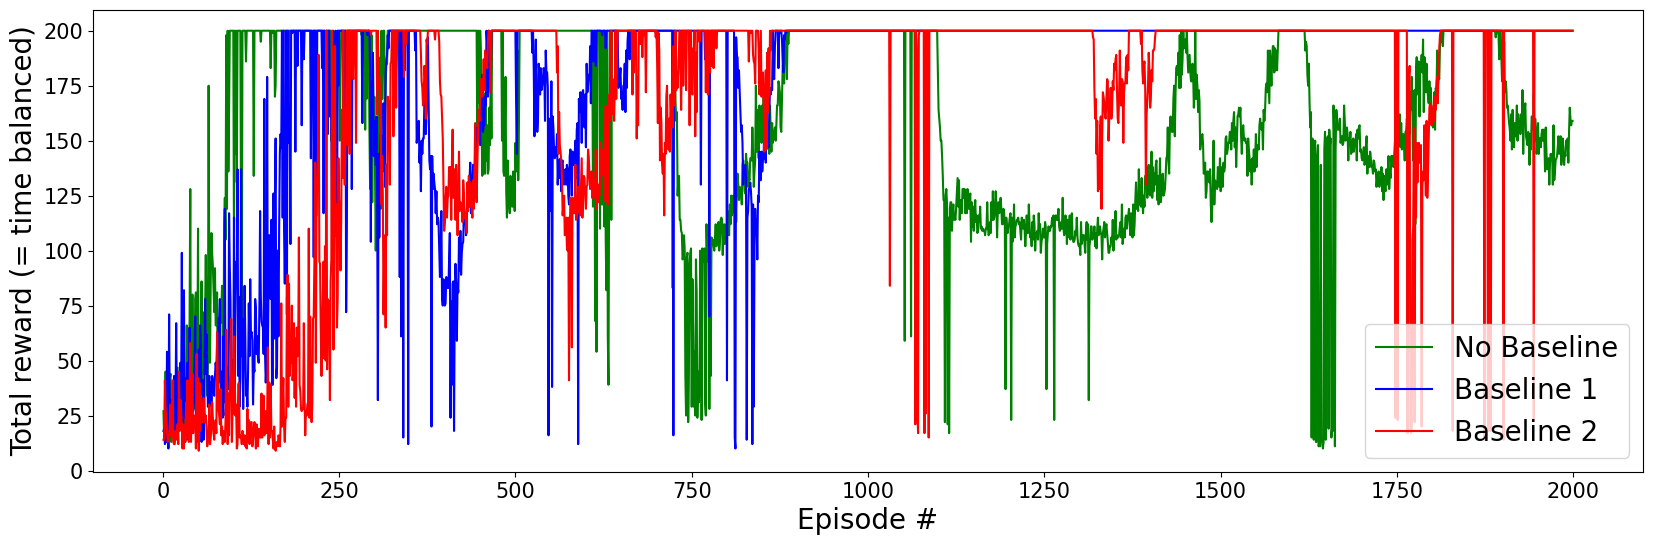

In [11]:
### Plot the learning progress

# Create the plot
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Plot the scores with specified colors and labels
ax.plot(np.arange(1, len(scores_rwd2go) + 1), scores_rwd2go, color='green', label='No Baseline')
ax.plot(np.arange(1, len(scores_baseline_1) + 1), scores_baseline_1, color='blue', label='Baseline 1')
ax.plot(np.arange(1, len(scores_baseline_2) + 1), scores_baseline_2, color='red', label='Baseline 2')

# Set the labels with a larger font size
ax.set_ylabel('Total reward (= time balanced)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)

# Set the tick labels to a larger font size
ax.tick_params(axis='both', which='major', labelsize=15)

# Add a legend with a specified font size
ax.legend(fontsize=20)

# Show the plot
plt.show()

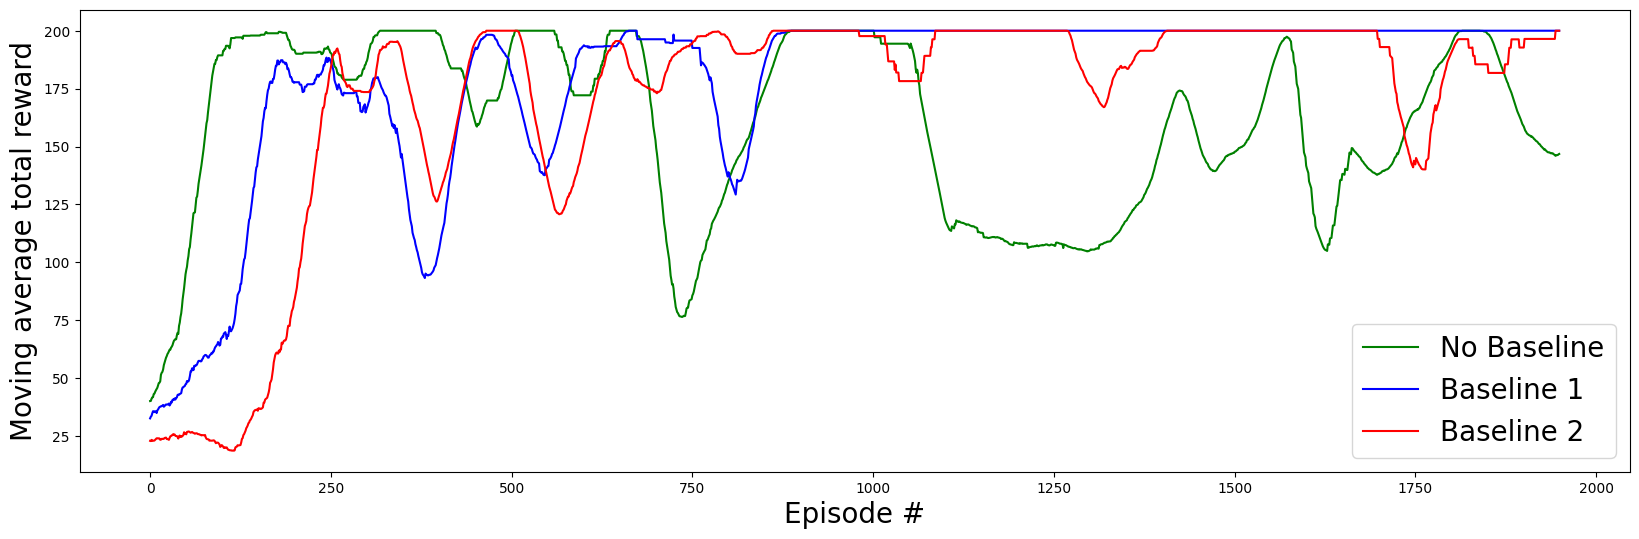

In [12]:
def moving_average(scores, window=50):
    return np.convolve(scores, np.ones(window) / window, mode="valid")

window = 50

fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

ax.plot(moving_average(scores_rwd2go, window), color='green', label="No Baseline",)
ax.plot(moving_average(scores_baseline_1, window), color='blue', label="Baseline 1",)
ax.plot(moving_average(scores_baseline_2, window), color='red', label="Baseline 2",)

ax.set_ylabel("Moving average total reward", fontsize=20)
ax.set_xlabel("Episode #", fontsize=20)
ax.legend(fontsize=20)
plt.show()

# $Q^\star$: Policy Gradient with continuous actions and bound on the bonuses count in OPPO (20 points)
***Question 1:*** Consider using a Gaussian parameterized policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathrm{R}^d$ 
and covariance matrix $\Sigma$ . Write down the following gradients:

$$ \nabla_\mu J(\pi_{\mu, \Sigma}) = ???$$
$$ \nabla_\Sigma J(\pi_{\mu, \Sigma}) = ???$$
***Question 2*** In this exercise, you will bound the state action counts. This is a crucial part of the OPPO convergence proof. Let $N^t_h(s,a)$ denotes the number of times the state action pair $s,a$ has been visited at step $h$ in all the episode up to $t$ included. Moreover,
let $s^t_h,a^t_h$ be the state action pair visited at step $h$ of the $t^{th}$ episode. Then, prove that 
$$ \sum^T_{t=1} \sum^H_{h=1} \frac{1}{N^t_h(s^t_h, a^t_h)+1} \leq SAH \log( T H)$$
***Question 3*** Use the fact above to prove the following bound at slide 30 of Lecture 5. That is, for $\mathrm{bonus}^t_h(s,a) = \frac{H}{\sqrt{N^t_h(s,a)+1}}$ it holds that
$$ \sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) \leq H^2 \sqrt{S A T \log( T H)}$$

### Question 1

Assume that the policy is a multivariate Gaussian policy

$$
\pi_{\mu,\Sigma}(a \mid s)
=
\mathcal{N}(a;\mu,\Sigma),
$$

where $\mu \in \mathbb{R}^d$ and $\Sigma \in \mathbb{R}^{d \times d}$ is positive definite.

Using the policy gradient theorem,

$$
\nabla_\theta J(\pi_\theta)
=
\frac{1}{1-\gamma}
\mathbb{E}_{s\sim \lambda_\mu^\pi,\ a\sim \pi_\theta(\cdot\mid s)}
\left[
Q^\pi(s,a)\nabla_\theta \log \pi_\theta(a\mid s)
\right].
$$

For a Gaussian policy, the log-density is

$$
\log \pi_{\mu,\Sigma}(a\mid s)
=
-\frac{d}{2}\log(2\pi)
-\frac{1}{2}\log |\Sigma|
-\frac{1}{2}(a-\mu)^\top \Sigma^{-1}(a-\mu).
$$

Therefore,

$$
\nabla_\mu \log \pi_{\mu,\Sigma}(a\mid s)
=
\Sigma^{-1}(a-\mu),
$$

and

$$
\nabla_\Sigma \log \pi_{\mu,\Sigma}(a\mid s)
=
\frac{1}{2}
\left[
\Sigma^{-1}(a-\mu)(a-\mu)^\top \Sigma^{-1}
-
\Sigma^{-1}
\right].
$$

Hence,

$$
\boxed{
\nabla_\mu J(\pi_{\mu,\Sigma})
=
\frac{1}{1-\gamma}
\mathbb{E}_{s\sim \lambda_\mu^\pi,\ a\sim \pi_{\mu,\Sigma}}
\left[
Q^\pi(s,a)\Sigma^{-1}(a-\mu)
\right]
}
$$

and

$$
\boxed{
\nabla_\Sigma J(\pi_{\mu,\Sigma})
=
\frac{1}{2(1-\gamma)}
\mathbb{E}_{s\sim \lambda_\mu^\pi,\ a\sim \pi_{\mu,\Sigma}}
\left[
Q^\pi(s,a)
\left(
\Sigma^{-1}(a-\mu)(a-\mu)^\top \Sigma^{-1}
-
\Sigma^{-1}
\right)
\right]
}
$$

Equivalently, $Q^\pi(s,a)$ can be replaced by the advantage
$A^\pi(s,a)$, since adding a baseline independent of the action does not
change the policy gradient.



### Question 2

We want to prove that

$$
\sum_{t=1}^T \sum_{h=1}^H
\frac{1}{N_h^t(s_h^t,a_h^t)+1}
\leq
SAH \log(TH).
$$

Fix a step $h \in \{1,\dots,H\}$ and a state-action pair $(s,a)$.
Let

$$
n_h^T(s,a)
$$

be the total number of visits to $(s,a)$ at step $h$ over all $T$
episodes.

Now consider only the terms in the sum corresponding to this fixed
triple $(h,s,a)$. Each time $(s,a)$ is visited at step $h$, the count
$N_h^t(s,a)$ increases by one.

Therefore, if the pair $(s,a)$ is visited $n_h^T(s,a)$ times at step
$h$, its contribution is bounded by a harmonic sum:

$$
\sum_{\substack{t:\ (s_h^t,a_h^t)=(s,a)}}
\frac{1}{N_h^t(s,a)+1}
\leq
\sum_{k=1}^{n_h^T(s,a)}
\frac{1}{k}.
$$

Using the classical bound

$$
\sum_{k=1}^n \frac{1}{k}
\leq
1+\log n
\leq
\log(TH),
$$

up to constants, since $n_h^T(s,a)\leq T \leq TH$, we get

$$
\sum_{\substack{t:\ (s_h^t,a_h^t)=(s,a)}}
\frac{1}{N_h^t(s,a)+1}
\leq
\log(TH).
$$

There are $H$ possible steps, $S$ possible states, and $A$ possible
actions. Summing over all triples $(h,s,a)$ gives

$$
\sum_{t=1}^T \sum_{h=1}^H
\frac{1}{N_h^t(s_h^t,a_h^t)+1}
\leq
\sum_{h=1}^H \sum_{s=1}^S \sum_{a=1}^A
\log(TH).
$$

Thus,

$$
\boxed{
\sum_{t=1}^T \sum_{h=1}^H
\frac{1}{N_h^t(s_h^t,a_h^t)+1}
\leq
SAH \log(TH)
}
$$

as required.



### Question 3

We now prove the bound for the OPPO bonus

$$
\mathrm{bonus}_h^t(s,a)
=
\frac{H}{\sqrt{N_h^t(s,a)+1}}.
$$

We want to bound

$$
\sum_{t=1}^T \sum_{h=1}^H
\mathrm{bonus}_h^t(s_h^t,a_h^t).
$$

Substituting the definition of the bonus gives

$$
\sum_{t=1}^T \sum_{h=1}^H
\mathrm{bonus}_h^t(s_h^t,a_h^t)
=
H
\sum_{t=1}^T \sum_{h=1}^H
\frac{1}{\sqrt{N_h^t(s_h^t,a_h^t)+1}}.
$$

Apply Cauchy-Schwarz:

$$
\sum_{t=1}^T \sum_{h=1}^H
\frac{1}{\sqrt{N_h^t(s_h^t,a_h^t)+1}}
\leq
\sqrt{
\left(\sum_{t=1}^T \sum_{h=1}^H 1\right)
\left(
\sum_{t=1}^T \sum_{h=1}^H
\frac{1}{N_h^t(s_h^t,a_h^t)+1}
\right)
}.
$$

Since

$$
\sum_{t=1}^T \sum_{h=1}^H 1 = TH,
$$

and from Question 2,

$$
\sum_{t=1}^T \sum_{h=1}^H
\frac{1}{N_h^t(s_h^t,a_h^t)+1}
\leq
SAH \log(TH),
$$

we obtain

$$
\sum_{t=1}^T \sum_{h=1}^H
\frac{1}{\sqrt{N_h^t(s_h^t,a_h^t)+1}}
\leq
\sqrt{TH \cdot SAH \log(TH)}.
$$

Therefore,

$$
\sum_{t=1}^T \sum_{h=1}^H
\mathrm{bonus}_h^t(s_h^t,a_h^t)
\leq
H \sqrt{TH \cdot SAH \log(TH)}.
$$

Simplifying,

$$
H \sqrt{TH \cdot SAH \log(TH)}
=
H \sqrt{SAH^2T \log(TH)}
=
\sqrt{H^2 \cdot SAH^2T \log(TH)}.
$$

Thus,

$$
\sum_{t=1}^T \sum_{h=1}^H
\mathrm{bonus}_h^t(s_h^t,a_h^t)
\leq
\sqrt{H^4SA T \log(TH)}
$$

Equivalently,

$$
\boxed{
\sum_{t=1}^T \sum_{h=1}^H
\mathrm{bonus}_h^t(s_h^t,a_h^t)
\leq
H^2\sqrt{SA T \log(TH)}
}
$$